In [1]:
%pip install astroML

  Using cached astroML-1.0.2.post1-py3-none-any.whl (134 kB)
  Using cached scikit_learn-1.3.2-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (11.1 MB)
  Using cached threadpoolctl-3.5.0-py3-none-any.whl (18 kB)
  Using cached joblib-1.4.2-py3-none-any.whl (301 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
# importing required modules
import matplotlib.pyplot as plt
from vasttools.query import Query
import pandas as pd

from vasttools.moc import VASTMOCS
from astropy import units as u

import numpy as np

from astropy.coordinates import SkyCoord

import scipy.stats as stats

from astroML.time_series import ACF_EK

In [6]:
# setting plot preferences
%matplotlib inline

In [4]:
psr_df = pd.read_csv('final_products/paper_df_postprocessed.csv')

In [5]:
raw_psr_meas = {}
dates = {}

In [5]:
for name in psr_df['JNAME'].values:
    psr_name = name
    
    if (np.isnan(psr_df[psr_df['JNAME']==name]['control_chi2'].iloc[0])):
        continue

    #query_coord = controls_df.sort_values('chi_squared', ascending=False).iloc[0]['skycoord']
    query_coord = SkyCoord(str(psr_df[psr_df['JNAME']==psr_name].iloc[0]['RAJD']) + " " + str(psr_df[psr_df['JNAME']==psr_name].iloc[0]['DECJD']), unit='deg')
    query = Query(coords=query_coord, epochs='all-vast', use_tiles=True, corrected_data=False)
    query.find_sources()

    psr_meas = query.results[0].measurements[query.results[0].measurements['freq']!=1367.5]
    
    raw_psr_meas[psr_name] = psr_meas
            
    dates[psr_name] = psr_meas['dateobs']
    

Stokes I images unavailable for epoch 1
Stokes I catalogues unavailable for epoch 1
Stokes I RMS maps unavailable for epoch 1
Stokes I images unavailable for epoch 2
Stokes I catalogues unavailable for epoch 2
Stokes I RMS maps unavailable for epoch 2
Stokes I images unavailable for epoch 3x
Stokes I catalogues unavailable for epoch 3x
Stokes I RMS maps unavailable for epoch 3x
Stokes I images unavailable for epoch 4x
Stokes I catalogues unavailable for epoch 4x
Stokes I RMS maps unavailable for epoch 4x
Stokes I images unavailable for epoch 5x
Stokes I catalogues unavailable for epoch 5x
Stokes I RMS maps unavailable for epoch 5x
Stokes I images unavailable for epoch 6x
Stokes I catalogues unavailable for epoch 6x
Stokes I RMS maps unavailable for epoch 6x
Stokes I images unavailable for epoch 7x
Stokes I catalogues unavailable for epoch 7x
Stokes I RMS maps unavailable for epoch 7x
Stokes I images unavailable for epoch 8
Stokes I catalogues unavailable for epoch 8
Stokes I RMS maps u

In [6]:
#using premade csv (alternative to above cell)
psr_meas_df = pd.read_csv('all_pulsar_measurements.csv')
psr_meas_df = psr_meas_df[psr_meas_df['detection']==True]  #removing nondetections

psr_meas_df.rename(columns={psr_meas_df.columns[0] : 'psr_name'}, inplace=True)
for i in psr_meas_df.index.values:
    psr_meas_df['dateobs'].loc[i] = pd.Timestamp(psr_meas_df['dateobs'].loc[i])

for name in psr_df['JNAME'].values:
    raw_psr_meas[name] = psr_meas_df[psr_meas_df['psr_name']==name].drop(columns=psr_meas_df.columns[0:2])
    dates[name] = psr_meas_df[psr_meas_df['psr_name']==name].drop(columns=psr_meas_df.columns[0:2])['dateobs']

/tmp/ipykernel_2854/1368620895.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  psr_meas_df['dateobs'].loc[i] = pd.Timestamp(psr_meas_df['dateobs'].loc[i])


In [7]:
dates_mjd = {name: (dates_.apply(pd.Timestamp.to_julian_date) - 2400000.5) for name, dates_ in dates.items()}

In [17]:
name = 'J1809-1943'

In [23]:
raw_psr_meas['J1708-3506']

,name,ra,dec,skycoord,stokes,fields,primary_field,epoch,field,sbid,...,spectral_curvature,spectral_index_err,spectral_curvature_err,rms_image,has_siblings,fit_is_estimate,spectral_index_from_TT,flag_c4,comment,detection
737,source_170817.6-350622.6,257.073426,-35.106289,"<SkyCoord (ICRS): (ra, dec) in deg\n (257.0...",I,['VAST_1651-37' 'VAST_1721-37' 'VAST_1724-31' ...,VAST_1721-37,23,VAST_1721-37,45672,...,-99.0,0.0,0.0,0.348,0.0,0.0,1.0,0.0,NaN,True
738,source_170817.6-350622.6,257.073426,-35.106289,"<SkyCoord (ICRS): (ra, dec) in deg\n (257.0...",I,['VAST_1651-37' 'VAST_1721-37' 'VAST_1724-31' ...,VAST_1721-37,23,VAST_1721-37,46052,...,-99.0,0.0,0.0,0.396,0.0,0.0,1.0,0.0,NaN,True
739,source_170817.6-350622.6,257.073426,-35.106289,"<SkyCoord (ICRS): (ra, dec) in deg\n (257.0...",I,['VAST_1651-37' 'VAST_1721-37' 'VAST_1724-31' ...,VAST_1721-37,23,VAST_1721-37,46803,...,-99.0,0.0,0.0,0.379,0.0,0.0,1.0,0.0,NaN,True
740,source_170817.6-350622.6,257.073426,-35.106289,"<SkyCoord (ICRS): (ra, dec) in deg\n (257.0...",I,['VAST_1651-37' 'VAST_1721-37' 'VAST_1724-31' ...,VAST_1721-37,23,VAST_1721-37,47061,...,-99.0,0.0,0.0,0.368,0.0,0.0,1.0,0.0,NaN,True
741,source_170817.6-350622.6,257.073426,-35.106289,"<SkyCoord (ICRS): (ra, dec) in deg\n (257.0...",I,['VAST_1651-37' 'VAST_1721-37' 'VAST_1724-31' ...,VAST_1721-37,23,VAST_1721-37,47250,...,-99.0,0.0,0.0,0.341,0.0,0.0,1.0,0.0,NaN,True
742,source_170817.6-350622.6,257.073426,-35.106289,"<SkyCoord (ICRS): (ra, dec) in deg\n (257.0...",I,['VAST_1651-37' 'VAST_1721-37' 'VAST_1724-31' ...,VAST_1721-37,23,VAST_1721-37,47625,...,-99.0,0.0,0.0,0.338,0.0,0.0,1.0,0.0,NaN,True
743,source_170817.6-350622.6,257.073426,-35.106289,"<SkyCoord (ICRS): (ra, dec) in deg\n (257.0...",I,['VAST_1651-37' 'VAST_1721-37' 'VAST_1724-31' ...,VAST_1721-37,23,VAST_1721-37,47690,...,-99.0,0.0,0.0,0.355,0.0,0.0,1.0,0.0,NaN,True
744,source_170817.6-350622.6,257.073426,-35.106289,"<SkyCoord (ICRS): (ra, dec) in deg\n (257.0...",I,['VAST_1651-37' 'VAST_1721-37' 'VAST_1724-31' ...,VAST_1721-37,24,VAST_1721-37,48258,...,-99.0,0.0,0.0,0.484,0.0,0.0,1.0,0.0,NaN,True
745,source_170817.6-350622.6,257.073426,-35.106289,"<SkyCoord (ICRS): (ra, dec) in deg\n (257.0...",I,['VAST_1651-37' 'VAST_1721-37' 'VAST_1724-31' ...,VAST_1721-37,25,VAST_1721-37,48461,...,-99.0,0.0,0.0,0.367,0.0,0.0,1.0,0.0,NaN,True
746,source_170817.6-350622.6,257.073426,-35.106289,"<SkyCoord (ICRS): (ra, dec) in deg\n (257.0...",I,['VAST_1651-37' 'VAST_1721-37' 'VAST_1724-31' ...,VAST_1721-37,26,VAST_1721-37,48850,...,-99.0,0.0,0.0,0.400,0.0,0.0,1.0,0.0,NaN,True


In [4]:
def find_point5(xp, fp):
    x = np.linspace(0, xp.max(), 1000)
    y = np.interp(x, xp, fp)
    for i in np.arange(1000):
        if y[i] < 0.5:
            return x[i]
    return np.nan

In [34]:
for name in ['J1722-3207']:
    t = dates_mjd[name] - dates_mjd[name].iloc[0]
    dy = raw_psr_meas[name]['rms_image']
    y_obs = raw_psr_meas[name]['flux_peak']

    #t = np.arange(1000)
    #dy = 0.1
    #y_obs = np.sin(0.01 * t)

    #------------------------------------------------------------
    # compute ACF via E-K method
    C_EK, C_EK_err, bins = ACF_EK(t, y_obs, dy, bins=np.linspace(0, int(t.max()/2), int(t.max()/14)))
    t_EK = 0.5 * (bins[1:] + bins[:-1])

    #------------------------------------------------------------
    # Plot the results
    fig = plt.figure(figsize=(6, 9))

    # plot the input data
    ax = fig.add_subplot(211)
    ax.errorbar(dates[name], y_obs, dy, fmt='.k', lw=1)
    ax.set_xlabel('Date')
    ax.set_ylabel('observed flux')

    fig.autofmt_xdate()
    plt.setp(ax.get_xticklabels(), visible=True)

    # plot the ACF
    ax = fig.add_subplot(212)

    ax.errorbar(t_EK, C_EK, C_EK_err, fmt='.k', lw=1,
                label='Edelson-Krolik')

    ax.plot(t_EK, 0 * t_EK, ':', lw=1, c='gray')
    
    t_point5 = find_point5(t_EK, C_EK)
    #t_point5 = t_EK[np.abs(C_EK - 0.5).argmin()]

    ax.axvline(t_point5, linestyle='dashed', label=("ACF ~ 0.5 at " + str(t_point5)))

    #t_minusone = t_EK[np.abs(C_EK + 1).argmin()]

    #ax.axvline(t_minusone, linestyle='dashed', color='orange', label=("ACF ~ -1 at " + str(t_minusone)))

    ax.legend(loc=3)

    ax.set_xlim(0, t.max() / 2)
    ax.set_ylim(-2.1, 2.1)

    ax.set_xlabel('Lag')
    ax.set_ylabel('ACF(t)')


    fig.suptitle(name, y=0.93)
    plt.savefig('ACF/' + name, bbox_inches='tight', pad_inches=2)
    plt.close()

In [29]:
times = []
names = []
for name in psr_df['JNAME'].values:
    t = dates_mjd[name] - dates_mjd[name].iloc[0]
    dy = raw_psr_meas[name]['rms_image']
    y_obs = raw_psr_meas[name]['flux_peak']

    #t = np.arange(1000)
    #dy = 0.1
    #y_obs = np.sin(0.01 * t)

    #------------------------------------------------------------
    # compute ACF via E-K method
    C_EK, C_EK_err, bins = ACF_EK(t, y_obs, dy, bins=np.linspace(0, int(t.max()/2), int(t.max()/14)))
    t_EK = 0.5 * (bins[1:] + bins[:-1])
    if (np.isnan(C_EK) == False).all():
        t_point5 = find_point5(t_EK, C_EK)
        times.append(t_point5)
        names.append(name)

/opt/conda/lib/python3.8/site-packages/astroML/time_series/ACF.py:114: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt((sigma ** 2 - dy ** 2) *
/opt/conda/lib/python3.8/site-packages/astroML/time_series/ACF.py:131: RuntimeWarning: invalid value encountered in true_divide
  ACF /= M
/opt/conda/lib/python3.8/site-packages/astroML/time_series/ACF.py:133: RuntimeWarning: divide by zero encountered in true_divide
  return ACF, np.sqrt(2. / M), bins


In [28]:
df = pd.read_csv('paper_df_w_scin_data.csv')

In [10]:
df.insert(7, 'ACF.5', np.nan) 

ValueError: cannot insert ACF.5, already exists

In [30]:
df['ACF.5'] = pd.Series(data=times, index=[0,1,2,3,4,5,6,7,8,9,10,11,13,15,29,31]).transpose()

In [ ]:
df

,Unnamed: 0,DOF,p_value,reduced_chi_squared,modulation,chi_squared,control_chi2,ACF.5,DECJD,RAJD,...,P0,AGE,GB,S1400,sm,err_sm,m,err_m,t0,err_t0
0,0,36,0.000000e+00,432.954315,26.654577,15586.355325,23.045368,13.812786,-30.673028,266.484650,...,0.367434,5.455155e+05,-0.963350,21.000,0.002331,0.000476,0.155003,0.006335,3.819045,0.468275
1,1,29,0.000000e+00,77.771774,61.218286,2255.381446,30.755787,6.304034,-27.292038,271.088055,...,0.009343,3.623779e+09,-2.735625,0.400,0.009488,0.001003,0.134667,0.002848,3.824800,0.242698
2,2,35,0.000000e+00,57.272650,12.860362,2004.542759,35.817563,104.109248,-32.129250,260.512329,...,0.477158,1.171749e+07,2.525185,5.400,0.011657,0.001410,0.127524,0.003085,4.688013,0.340203
3,3,25,9.437150e-150,31.451305,45.110077,786.282634,18.571723,7.880042,-19.731092,272.462862,...,5.540743,3.104126e+04,-0.158392,0.680,0.011247,0.001181,0.113305,0.002380,9.735480,0.613484
4,4,35,2.005980e-54,10.118445,23.131911,354.145567,55.885095,47.084585,-29.554512,260.142155,...,0.620448,1.317751e+07,4.247527,1.690,0.004188,0.000664,0.170646,0.005408,1.508967,0.143461
5,5,36,2.479878e-53,9.754599,17.432562,351.165548,39.535853,8.500176,-29.343917,270.445162,...,1.081910,5.206639e+06,-3.248970,2.600,0.001943,0.000249,0.190309,0.004884,1.243665,0.095753
6,6,33,1.409647e-19,5.017188,24.190171,165.567203,39.535853,9.828328,-28.979613,271.006347,...,0.001493,NaN,-3.497526,0.918,0.004792,0.000533,0.160830,0.003581,1.986068,0.132668
7,7,33,3.875847e-19,4.941890,27.874017,163.082363,36.531219,19.962774,-22.092500,269.850683,...,0.460982,6.729418e+05,0.809664,1.300,0.004833,0.000537,0.134057,0.002977,5.891304,0.392496
8,8,35,6.537434e-13,3.724819,20.075910,130.368671,56.818976,10.506723,-19.249444,268.396546,...,0.062955,4.934764e+08,3.412333,0.130,0.004058,0.000457,0.165583,0.003731,1.842446,0.124560
9,9,34,3.999283e-12,3.639070,11.859582,123.728388,52.625404,7.617374,-24.088451,272.832725,...,0.002661,3.060089e+09,-2.558998,1.330,0.007256,0.000784,0.140518,0.003038,3.480793,0.225756


In [36]:
df.drop(columns=df.columns[0])

,DOF,p_value,reduced_chi_squared,modulation,chi_squared,control_chi2,ACF.5,DECJD,RAJD,P1,...,P0,AGE,GB,S1400,sm,err_sm,m,err_m,t0,err_t0
0,36,0.000000e+00,432.954315,26.654577,15586.355325,23.045368,13.812786,-30.673028,266.484650,1.067181e-14,...,0.367434,5.455155e+05,-0.963350,21.000,0.002331,0.000476,0.155003,0.006335,3.819045,0.468275
1,29,0.000000e+00,77.771774,61.218286,2255.381446,30.755787,6.304034,-27.292038,271.088055,4.085000e-20,...,0.009343,3.623779e+09,-2.735625,0.400,0.009488,0.001003,0.134667,0.002848,3.824800,0.242698
2,35,0.000000e+00,57.272650,12.860362,2004.542759,35.817563,104.109248,-32.129250,260.512329,6.451988e-16,...,0.477158,1.171749e+07,2.525185,5.400,0.011657,0.001410,0.127524,0.003085,4.688013,0.340203
3,25,9.437150e-150,31.451305,45.110077,786.282634,18.571723,7.880042,-19.731092,272.462862,2.828099e-12,...,5.540743,3.104126e+04,-0.158392,0.680,0.011247,0.001181,0.113305,0.002380,9.735480,0.613484
4,35,2.005980e-54,10.118445,23.131911,354.145567,55.885095,47.084585,-29.554512,260.142155,7.459989e-16,...,0.620448,1.317751e+07,4.247527,1.690,0.004188,0.000664,0.170646,0.005408,1.508967,0.143461
5,36,2.479878e-53,9.754599,17.432562,351.165548,39.535853,8.500176,-29.343917,270.445162,3.292304e-15,...,1.081910,5.206639e+06,-3.248970,2.600,0.001943,0.000249,0.190309,0.004884,1.243665,0.095753
6,33,1.409647e-19,5.017188,24.190171,165.567203,39.535853,9.828328,-28.979613,271.006347,-7.573344e-22,...,0.001493,NaN,-3.497526,0.918,0.004792,0.000533,0.160830,0.003581,1.986068,0.132668
7,33,3.875847e-19,4.941890,27.874017,163.082363,36.531219,19.962774,-22.092500,269.850683,1.085356e-14,...,0.460982,6.729418e+05,0.809664,1.300,0.004833,0.000537,0.134057,0.002977,5.891304,0.392496
8,35,6.537434e-13,3.724819,20.075910,130.368671,56.818976,10.506723,-19.249444,268.396546,2.021292e-18,...,0.062955,4.934764e+08,3.412333,0.130,0.004058,0.000457,0.165583,0.003731,1.842446,0.124560
9,34,3.999283e-12,3.639070,11.859582,123.728388,52.625404,7.617374,-24.088451,272.832725,1.377560e-20,...,0.002661,3.060089e+09,-2.558998,1.330,0.007256,0.000784,0.140518,0.003038,3.480793,0.225756


In [37]:
df.drop(columns=df.columns[0]).to_csv('paper_df_w_scin_data.csv')

In [69]:
dy

517    0.257
518    0.233
519    0.257
520    0.252
521    0.252
522    0.238
523    0.251
524    0.328
525    0.252
526    0.269
527    0.258
528    0.302
529    0.256
530    0.238
531    0.246
532    0.264
533    0.243
534    0.260
535    0.247
536    0.257
537    0.247
538    0.241
539    0.271
540    0.240
541    0.239
542    0.267
543    0.273
544    0.269
545    0.271
546    0.362
547    0.337
548    0.291
549    0.332
550    0.277
551    0.248
552    0.220
553    0.293
Name: rms_image, dtype: float64

In [41]:
np.std(y_obs)**2-dy**2

1111    -5.923175
1112    -5.799535
1113    -2.378269
1114    -0.809857
1115    -4.944694
1116    -2.329089
1117    -3.820054
1118    -1.661569
1119    -3.260743
1120    -9.520198
1121    -4.208695
1122    -8.584989
1123    -5.572909
1124    -5.469702
1125    -4.555357
1126    -5.288982
1127     0.373343
1128    -1.098694
1129    -3.602374
1130     1.253183
1131    -1.146973
1132    -2.627169
1133    -0.070573
1134     1.333731
1135    -0.839614
1136    -0.826849
1137    -2.597037
1138    -6.110135
1139    -2.994369
1140    -0.831103
1141     0.203603
1142   -13.347355
1143    -0.444129
1144    -7.636929
1145    -4.595614
1146    -4.950574
1147    -1.689373
1148     1.142618
1149    -3.607777
Name: rms_image, dtype: float64

In [57]:
for name in psr_df['JNAME'].values:
    if not raw_psr_meas[name]['flux_peak'].isnull().values.any():
        print(name)

J1745-3040
J1722-3207
J1720-2933
J1801-2920
J1811-2405
J1801-2304
J1759-3107
J1750-3157
J1816-2650
J1749-3002
J1738-3211
J1721-3532


In [82]:
stuff = ['J1745-3040', 'J1722-3207', 'J1720-2933']

df0 = raw_psr_meas[stuff[0]][['dateobs', 'flux_peak', 'rms_image']]
df1 = raw_psr_meas[stuff[1]][['dateobs', 'flux_peak', 'rms_image']]
df2 = raw_psr_meas[stuff[2]][['dateobs', 'flux_peak', 'rms_image']]

pd.concat([df0, df1, df2], keys=stuff).to_csv('test_lightcurves.csv')

In [38]:
df[['JNAME', 'ACF.5', 't0', 'modulation', 'm']]

,JNAME,ACF.5,t0,modulation,m
0,J1745-3040,13.812786,3.819045,26.654577,0.155003
1,J1804-2717,6.304034,3.824800,61.218286,0.134667
2,J1722-3207,104.109248,4.688013,12.860362,0.127524
3,J1809-1943,7.880042,9.735480,45.110077,0.113305
4,J1720-2933,47.084585,1.508967,23.131911,0.170646
5,J1801-2920,8.500176,1.243665,17.432562,0.190309
6,J1804-2858,9.828328,1.986068,24.190171,0.160830
7,J1759-2205,19.962774,5.891304,27.874017,0.134057
8,J1753-1914,10.506723,1.842446,20.075910,0.165583
9,J1811-2405,7.617374,3.480793,11.859582,0.140518


Text(0, 0.5, 'ACF(t)')

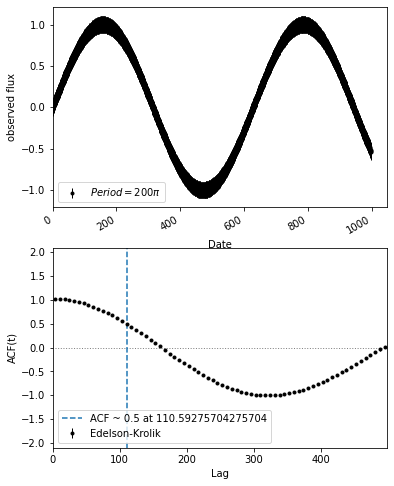

In [15]:
t = np.arange(1000)
dy = 0.1
y_obs = np.sin(0.01 * t)

#------------------------------------------------------------
# compute ACF via E-K method
C_EK, C_EK_err, bins = ACF_EK(t, y_obs, dy, bins=np.linspace(0, int(t.max()/2), int(t.max()/14)))
t_EK = 0.5 * (bins[1:] + bins[:-1])

#------------------------------------------------------------
# Plot the results
fig = plt.figure(figsize=(6, 9))

# plot the input data
ax = fig.add_subplot(211)
ax.errorbar(t, y_obs, dy, fmt='.k', lw=1, label='$Period = 200\pi$')
ax.set_xlabel('Date')
ax.set_ylabel('observed flux')

fig.autofmt_xdate()
ax.set_xlim(0)
ax.legend()
plt.setp(ax.get_xticklabels(), visible=True)

# plot the ACF
ax = fig.add_subplot(212)

ax.errorbar(t_EK, C_EK, C_EK_err, fmt='.k', lw=1,
            label='Edelson-Krolik')

ax.plot(t_EK, 0 * t_EK, ':', lw=1, c='gray')

t_point5 = find_point5(t_EK, C_EK)
#t_point5 = t_EK[np.abs(C_EK - 0.5).argmin()]

ax.axvline(t_point5, linestyle='dashed', label=("ACF ~ 0.5 at " + str(t_point5)))

#t_minusone = t_EK[np.abs(C_EK + 1).argmin()]

#ax.axvline(t_minusone, linestyle='dashed', color='orange', label=("ACF ~ -1 at " + str(t_minusone)))

ax.legend(loc=3)

ax.set_xlim(0, t.max() / 2)
ax.set_ylim(-2.1, 2.1)

ax.set_xlabel('Lag')
ax.set_ylabel('ACF(t)')

In [14]:
200 * np.pi / t_point5

5.6813714344334505